In [2]:
#iMPORTED lIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
#lOADED THEB DATASET

df = pd.read_csv("cleaned_retail_sales_dataset.csv")   

In [6]:
df.shape
#First 5 Rows
df.head()
#Last 5 Rows
df.tail()
#Column Names
df.columns
#Data Types
df.dtypes
#Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [8]:
df.isnull().sum()# MISSING VALUES
df.duplicated().sum()# DUPLICATE VALUES

np.int64(0)

In [13]:
#DESCRIPTIVE STATISTICS
df.describe()
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode().iloc[0]
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [16]:
#CONVERT THE DATE
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter

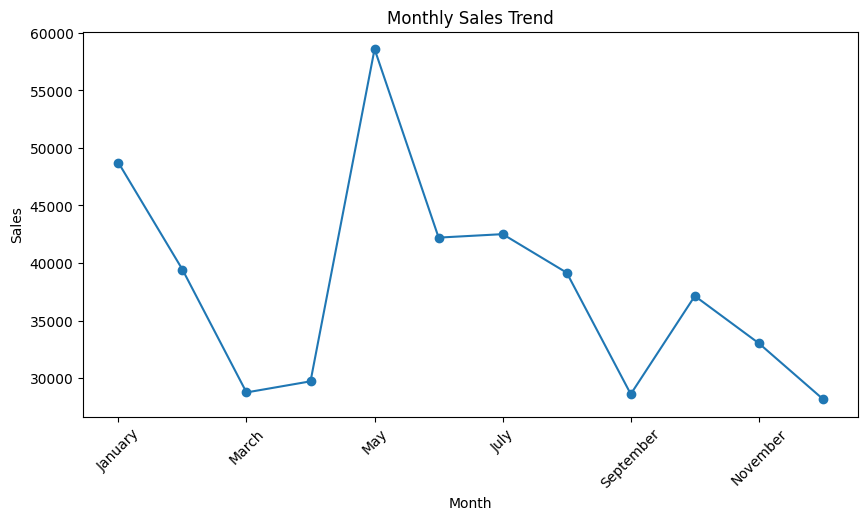

In [17]:
#MONTHLY SALES TREND
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales = monthly_sales.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Observation:

Sales fluctuated throughout the year, with the highest sales recorded in May (around 58K).
Sales declined after May, with relatively lower sales observed in March, September, and December.
The trend indicates seasonal variations in customer purchasing behavior.

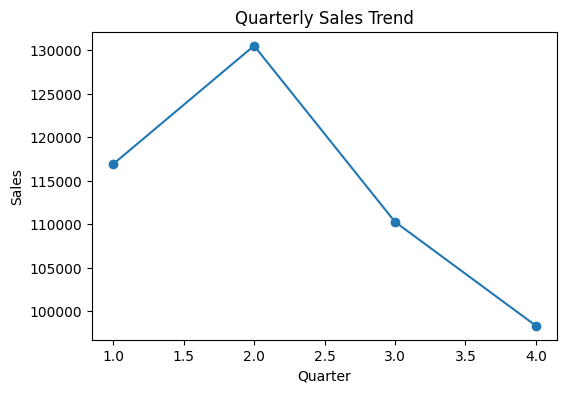

In [18]:
#QUARTERLY SALES TREND
quarter_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(6,4))
quarter_sales.plot(kind='line',marker='o')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

OObservation:

Quarter 2 (Q2) recorded the highest overall sales, followed by Q1.
Sales gradually declined during Q3 and reached the lowest level in Q4.
The results suggest stronger business performance during the first half of the year.

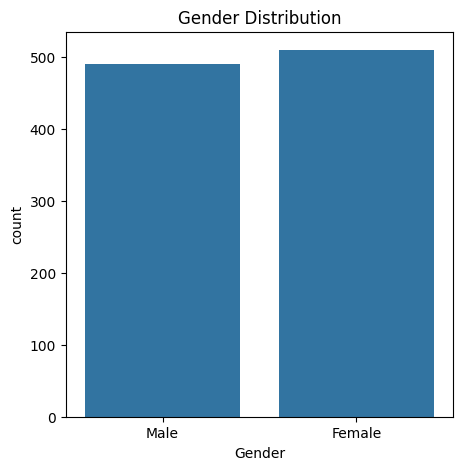

In [19]:
#GENDER DITRIBUTION
plt.figure(figsize=(5,5))
sns.countplot(data=df,x='Gender')
plt.title("Gender Distribution")
plt.show()

OObservation:

The customer distribution is almost balanced between male and female customers.
Female customers slightly outnumber male customers in the dataset.
This indicates that the business attracts customers from both genders equally.

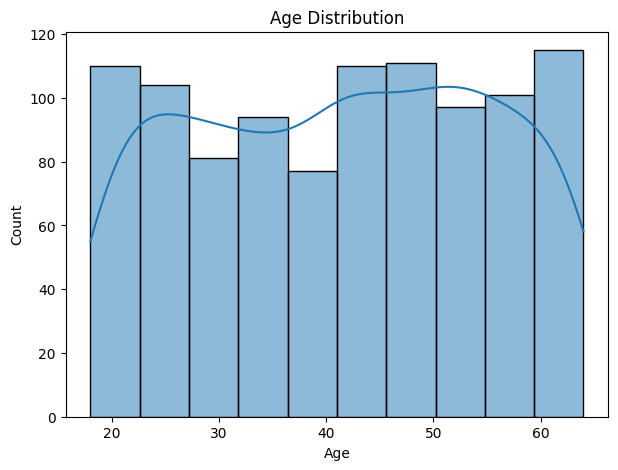

In [20]:
#AGE DISTRIBUTUON
plt.figure(figsize=(7,5))
sns.histplot(df['Age'],bins=10,kde=True)
plt.title("Age Distribution")
plt.show()

OObservation:

Customers are distributed across a wide age range, approximately 18 to 64 years.
Most purchases come from customers in the 20–60 years age group.
The business serves a diverse customer base without relying on a single age segment.

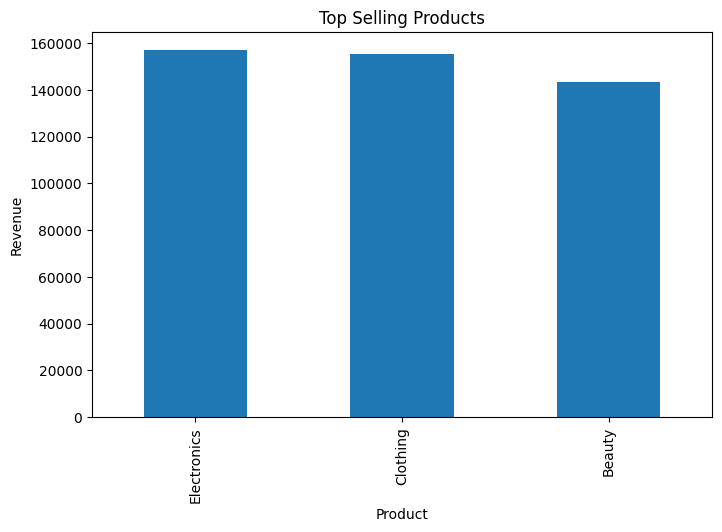

In [21]:
#TOP 10 PRODUCTS
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

Observation:

Electronics generated the highest revenue, closely followed by Clothing.
Beauty products contributed comparatively lower revenue.
Electronics and Clothing are the major revenue-driving product categories.

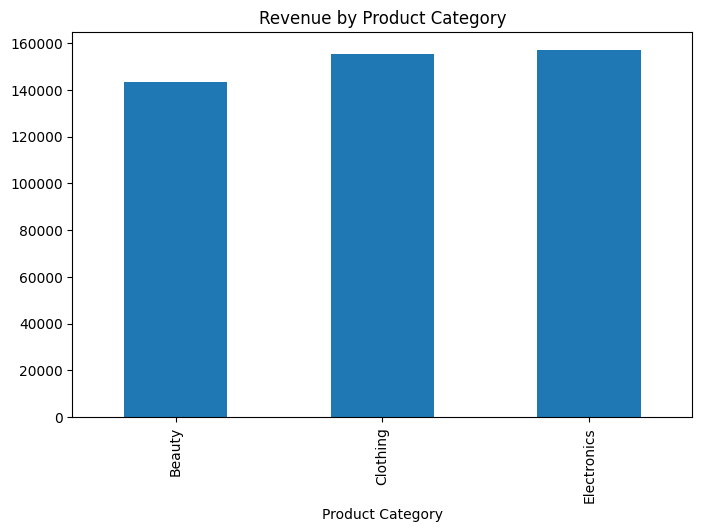

In [22]:
#REVENUE BY CATEGORY
category_sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.show()

Observation:

Electronics recorded the highest revenue among all product categories.
Clothing also performed strongly, while Beauty generated the lowest revenue.
The business should continue focusing on high-performing product categories to maximize revenue.

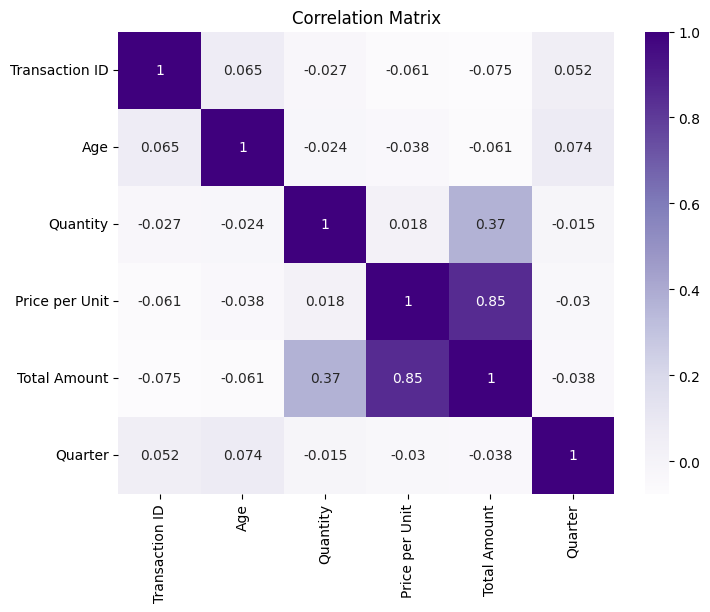

In [23]:
#CORRELATION HEATMAP
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='Purples')

plt.title("Correlation Matrix")
plt.show()

Observation:

Price per Unit has a strong positive correlation (0.85) with Total Amount, indicating that higher-priced products contribute to higher sales value.
Quantity shows a moderate positive correlation (0.37) with Total Amount.
Other variables have weak correlations, suggesting minimal linear relationships.

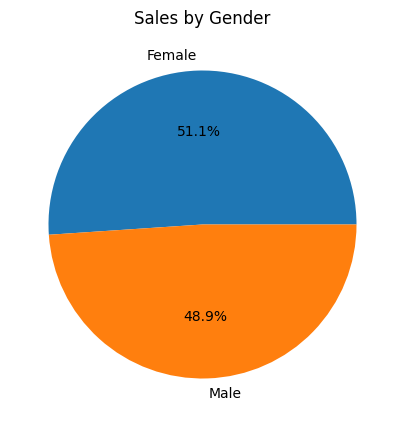

In [24]:
#ADDITIONAL VISUALIZATION (SALES BY GENDER)
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(5,5))
gender_sales.plot(kind='pie',autopct='%1.1f%%')
plt.ylabel("")
plt.title("Sales by Gender")
plt.show()

Observation:

Female customers contributed 51.1% of total sales, while male customers contributed 48.9%.
The sales contribution is nearly equal, with a slight dominance by female customers.
Marketing strategies can effectively target both customer groups.

Business Recommendations:
Focus inventory and promotional efforts on Electronics and Clothing, as they generate the highest revenue.
Plan marketing campaigns and stock availability around Quarter 2, when sales peak.
Introduce targeted offers for Beauty products to improve their sales performance.

cONCLUSION:
The analysis identified key sales trends, customer behavior, and product performance, with Electronics emerging as the highest revenue-generating category.
Sales peaked in Quarter 2, while customer purchases were almost equally distributed between male and female customers.
The insights gained from EDA can support inventory optimization, targeted marketing strategies, and data-driven business decision-making.